<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/YB%2011.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 평균 이동
### 평균 이동(Mean Shift)의 개요

*   평균 이동은 K-평균과 유사하게 중심을 군집의 중심으로 지속적으로 움직이면서 군집화를 수행한다. 하지만 K-평균이 중심에 소속된 데이터의 평균 거리 중심으로 이동하는 데 반해, 평균 이동은 중심을 데이터가 모여 있는 밀도가 가장 높은 곳으로 이동시킨다.

*   평균 이동 군집화는 데이터의 분포도를 이용해 군집 중심점을 찾는다. 군집 중심점은 데이터 포인트가 모여 있는 곳이라는 생각에서 착안한 것이며, 이를 위해 확률밀도함수를 이용한다. 가장 집중적으로 데이터가 모여 있어 PDF가 peak인 점을 군집 중심점으로 선정하며, 일반적으로 주어진 모델의 PDF를 찾기 위해 KDE(Kernel Density Estimation)를 이용한다.
*   평균 이동 군집화는 특정 데이터를 반경 내의 데이터 분포 확률 밀도가 가장 높은 곳으로 이동하기 위해, 주변 데이터와의 거리 값을 KDE 함수 값으로 입력한 뒤 그 반환 값을 현재 위치에서 업데이트하면서 이동하는 방식을 취한다. 이러한 방식을 전체 데이터에 반복적으로 적용하면서 데이터의 군집 중심점을 찾아낸다.
*   KDE(Kernel Density Estimation)는 커널(Kernel) 함수를 통해 어떤 변수의 PDF를 추정하는 대표적인 방법이다. 관측된 데이터 각각에 커널 함수를 적용한 값을 모두 더한 뒤 PDF를 추정한다. PDF를 알면 특정 변수가 어떤 값을 갖게 될지에 대한 확률을 알게 되기 때문이다. KDE는 개별 관측 데이터에 커널 함수를 적용한 뒤, 이 적용값을 모두 더한 후 개별 관측 데이터의 건수로 나눠 PDF를 추정하며, 대표적인 커널 함수로 가우시안 분포 함수가 사용된다.
*  KDE는 다음과 같은 함수식으로 표현된다. (K: 커널 함수, x: 확률변숫값, xi: 관측값, h: 대역폭)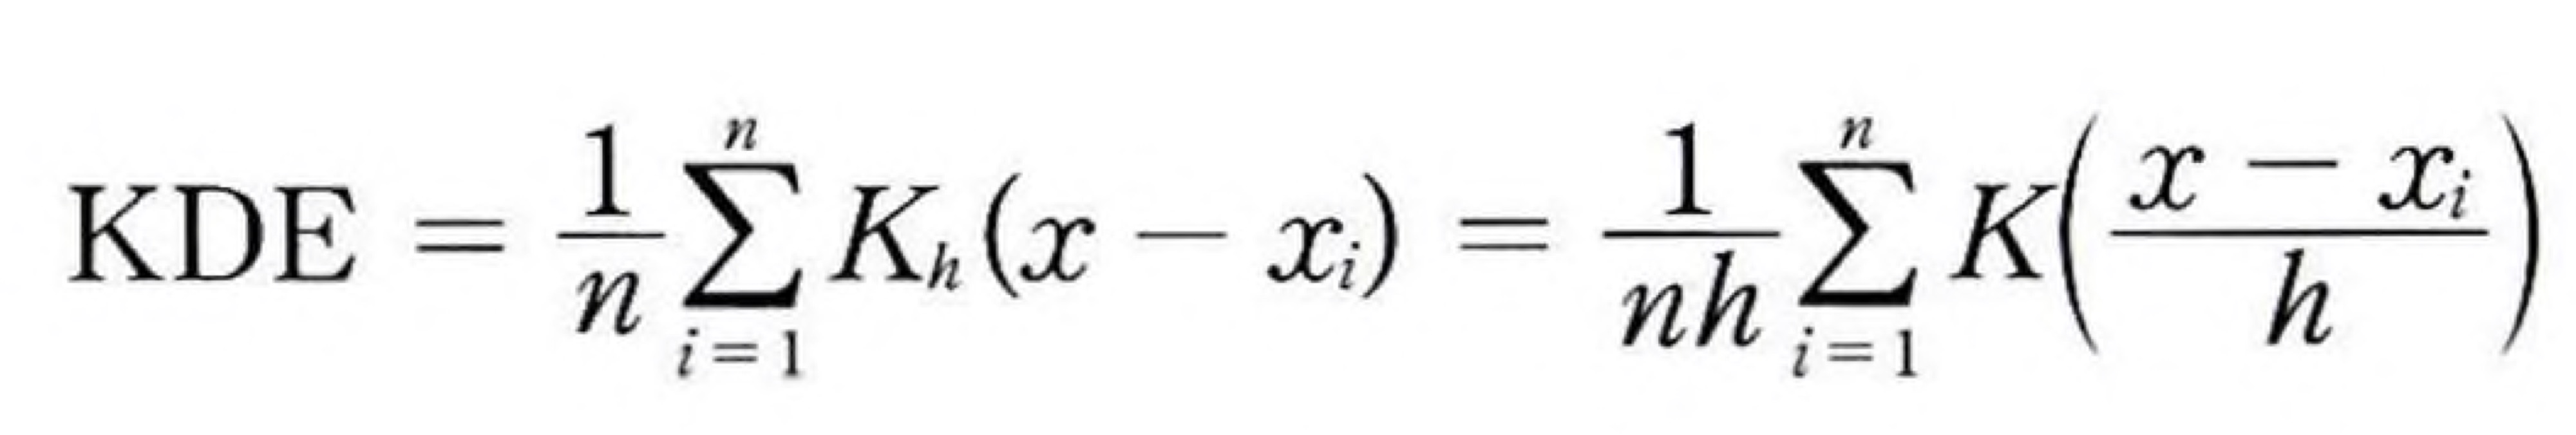





*   대역폭 h는 KDE 형태를 부드러운, 또는 뾰족한 형태로 평활화(Smoothing)하는 데 적용되며, 이 h를 어떻게 설정하느냐에 따라 확률 밀도 추정 성능을 크게 좌우할 수 있다. 작은 h 값(e.g. 1.0)은 좁고 뾰족한 KDE를 가지게 되며, 이는 변동성이 큰 방식으로 PDF를 추정하므로 과적합하기 쉽다. 반대로 매우 큰 h 값(e.g. 10)은 과도하게 평활화된 KDE로 인해 지나치게 단순화된 방식으로 PDF를 추정하며 결과적으로 과소적합(under-fitting)하기 쉽다. 따라서 적절한 KDE의 대역폭 h를 계산하는 것은 KDE 기반의 평균 이동 군집화에서 매우 중요하다.
*   사이킷런은 평균 이동 군집화를 위해 MeanShift 클래스를 제공한다. MeanShift 클래스의 가장 중요한 초기화 파라미터는 bandwidth이며, 이 파라미터는 KDE의 대역폭 h와 동일하다. 대역폭 크기 설정이 군집화의 품질에 큰 영향을 미치기 때문에 사이킷런은 최적의 대역폭 계산을 위해 estimate_bandwidth() 함수를 제공한다.

In [1]:
## make_blobs()의 cluster_std를 0.7로 정한 3개 군집의 데이터에 대해 bandwidth를 0.8로 설정한 평균 이동 군집화 알고리즘을 적용한다
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.7, random_state=0)

meanshift = MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2 3 4 5]


In [2]:
## bandwidth를 1.0로 상향 조정하여 Meanshift를 수행한다
meanshift = MeanShift(bandwidth=1)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]




*   일반적으로 bandwidth 값을 작게 할수록 군집 개수는 많아진다. 데이터의 분포 유혀에 따라 bandwidth 값의 변화는 군집화 개수에 큰 영향을 미칠 수 있다. 따라서 MeanShift에서는 이 bandwidth를 최적화 값으로 설정하는 것이 매우 중요하다. 사이킷런은 최적화된 bandwidth 값을 찾기 위해 estimate_bandwidth() 함수를 제공한다. estimate_bandwidth()의 파라미터로 피처 데이터 세트를 입력하면 최적화된 bandwidth 값을 반환해준다.


In [3]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
print('bandwidth 값: ', round(bandwidth, 3))

bandwidth 값:  1.816


In [5]:
## estimate_bandwidth()로 측정된 bandwidth를 평균 이동 입력값으로 적용해 동일한 make_blobs() 데이터 세트에 군집화를 수행한다
import pandas as pd

clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

## estimator_bandwidth()로 최적의 bandwidth를 계산한다
best_bandwidth = estimate_bandwidth(X)

meanshift = MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]




*   평균 이동도 K-평균과 유사하게 중심을 가지고 있으므로 cluster_centers_ 속성으로 군집 중심 좌표를 표시할 수 있다.


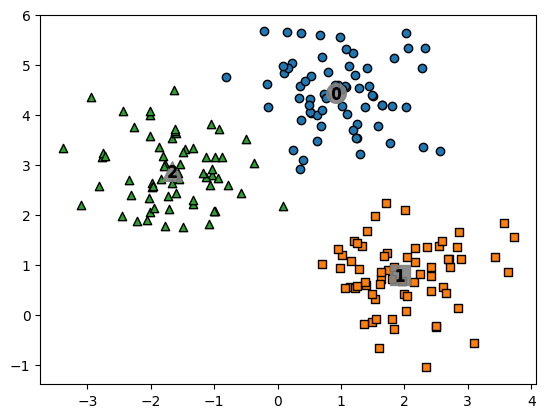

In [7]:
## 구성된 3개의 군집을 시각화한다
import matplotlib.pyplot as plt
%matplotlib inline

clusterDF['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = clusterDF[clusterDF['meanshift_label'] == label]
    center_x_y = centers[label]
    ## 군집별로 다른 마커를 산점도에 적용한다
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])
    ## 군집별 중심을 표현한다
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9, marker=markers[label])
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$' % label)

plt.show()

In [8]:
## target 값과 군집 label 값을 비교한다
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64




*   평균 이동의 장점은 데이터 세트의 형태를 특정 형태로 가정한다든가, 특정 분포도 기반의 모델로 가정하지 않기 때문에 좀 더 유연한 군집화가 가능한 점이다. 또, 이상치의 영향력도 크지 않으며, 미리 군집의 개수를 정할 필요도 없다.
*   하지만 평균 이동은 알고리즘의 수행 시간이 오래 걸리고 무엇보다도 bandwidth의 크기에 따른 군집화 영향도가 매우 크다는 단점이 있다. 이 같은 특징 때문에 일반적으로 평균 이동 군집화 기법은 분석 업무 기반의 데이터 세트보다는 컴퓨터 비전 영역에서 더 많이 사용되며 이미지나 영상 데이터에서 특정 개체를 구분하거나 움직임을 추적하는 데 뛰어난 역할을 수행한다.

## GMM(Gaussian Mixture Model)
### GMM(Gaussian Mixture Model) 소개


*   GMM 군집화는 군집화를 적용하고자 하는 데이터가 여러 개의 가우시안 분포(Gaussian Distribution)을 가진 데이터 집합들이 섞여서 생성된 것이라는 가정 하에 군집화를 수행하는 방식이다. 가우시안 분포는 정규분포로도 알려진 좌우 대칭형 종 형태의 분포이다. GMM은 섞인 데이터 분포에서 개별 유형의 가우시안 분포를 추출한다.
*   그림 1과 같이 세 개의 가우시안 분포 A, B, C를 가진 데이터 세트가 있다고 가정하면, 이 세 개의 정규 분포를 합쳤을 때 그림 3과 같은 형태가 된다. 군집화를 수행하려는 실제 데이터 세트의 데이터 분포도가 다음과 같다면 쉽게 이 데이터 세트가 정규분포 A, B, C가 합쳐서 된 데이터 분포도임을 알 수 있다. 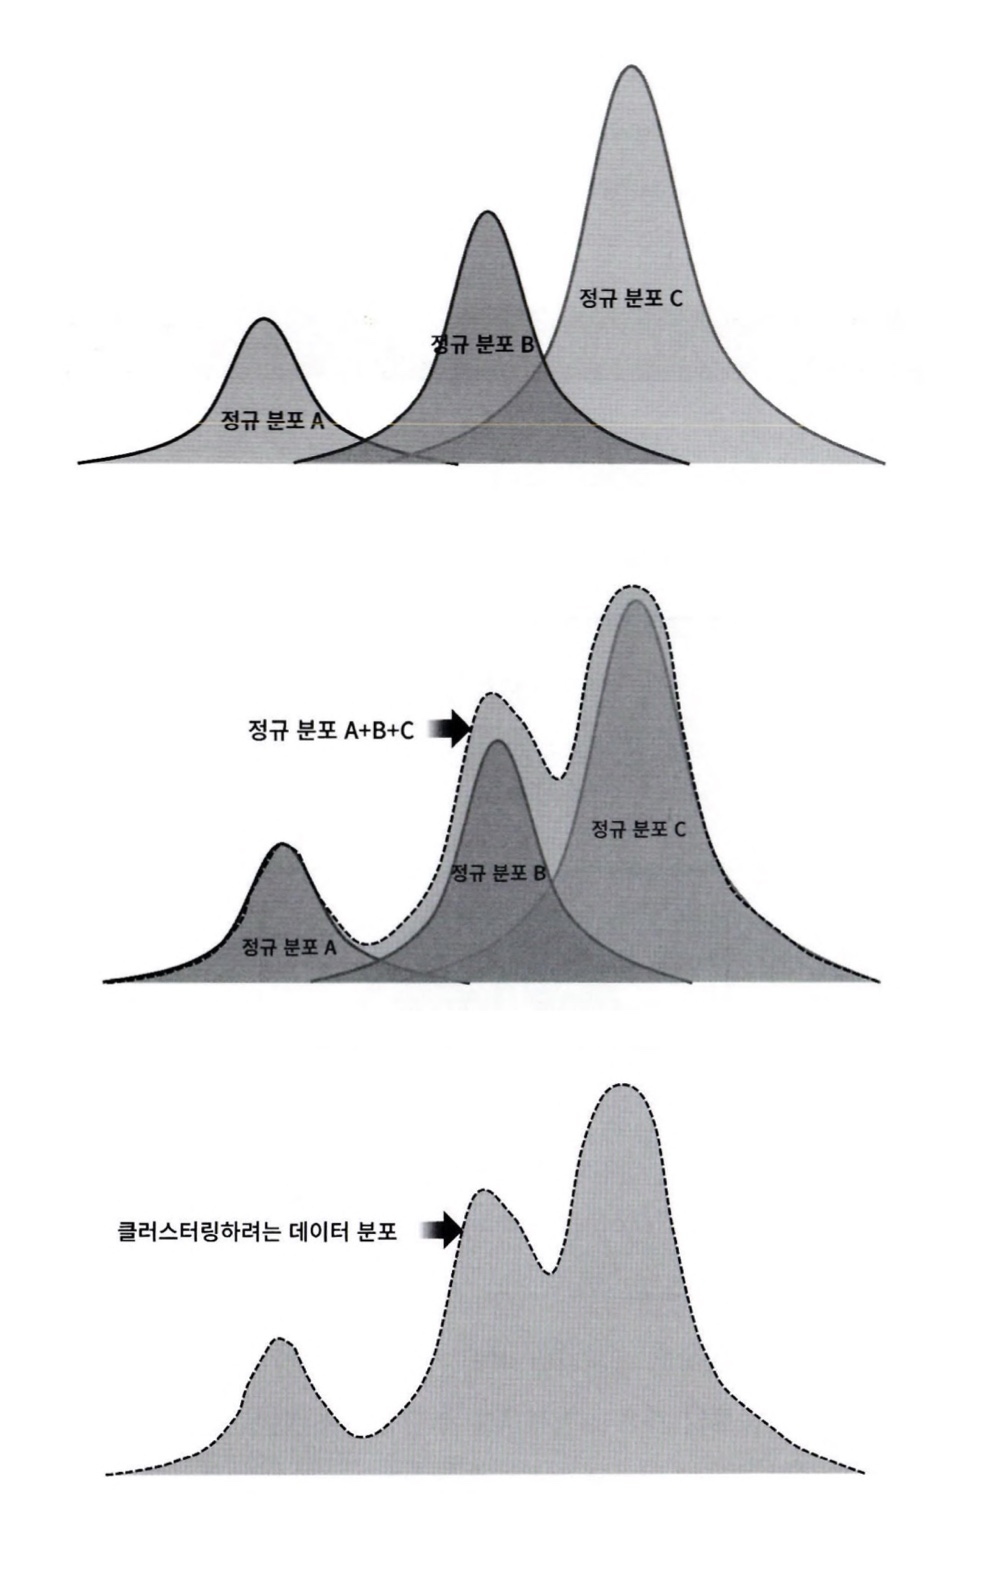




*   전체 데이터 세트는 서로 다른 정규 분포 형태를 가진 여러가지 확률 분포 곡선으로 구성될 수 있으며, 이러한 서로 다른 정규 분포에 기반해 군집화를 수행하는 것이 GMM 군집화 방식이다. 가령 1000개의 데이터 세트가 있다면 이를 구성하는 여러 개의 정규분포 곡선을 추출하고, 개별 데이터가 이 중 어떤 정규분포에 속하는지 결정하는 방식이다. 이와 같은 방식은 GMM에서 모수 추정이라고 하는데, 모수 추정은 대표적으로 (1) 개별 정규분포의 평균과 분산 (2) 각 데이터가 어떤 정규분포에 해당되는지에 대한 확률을 추청하는 것을 말한다.
*   모수 추정을 위해 GMM은 EM(Expectation and Maximization) 방법을 적용한다. 사이킷런은 GMM의 EM 방식을 통한 모수 추정 군집화를 지원하기 위해 GaussianMixture 클래스를 지원한다.

### GMM을 이용한 붓꽃 데이터 세트 군집화

*   GMM은 확률 기반 군집화이고 K-평균은 거리 기반 군집화이다.






In [9]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

## 좀 더 편리한 데이터 Handling을 위해 DataFrame으로 변환한다
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
irisDF['target'] = iris.target



*   GaussianMixture 객체의 가장 중요한 초기화 파라미터는 n_components이다. n_components는 gaussian mixture의 모델의 총 개수로, K-평균의 n_clusters와 같이 군집의 개수를 정하는 데에 중요한 역할을 수행한다. (* GaussianMixture 클래스는 sklearn.mixture 패키지에 위치해 있음에 유의해야 한다.)



In [10]:
## n_components를 3으로 설정하고 GaussianMixture로 군집화를 수행한다
from sklearn.mixture import GaussianMixture

## GaussianMixture 객체의 fit(피처 데이터 세트)와 predict(피처 데이터 세트)를 수행해 군집을 결정한다
gmm = GaussianMixture(n_components=3, random_state=0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

## 군집화 결과를 irisDF의 'gmm_cluster' 칼럼명으로 저장한다
irisDF['gmm_cluster'] = gmm_cluster_labels
irisDF['target'] = iris.target

## target 값에 따라 gmm_cluster 값이 어떻게 매핑됐는지 확인한다
iris_result = irisDF.groupby(['target'])['gmm_cluster'].value_counts()
print(iris_result)

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


In [11]:
## 붓꽃 데이터 세트의 K-평균 군집화를 수행한 결과와 비교한다
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)
irisDF['kmeans_cluster'] = kmeans_cluster_labels
iris_result = irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


붓꽃 데이터 세트는 GMM 군집화에 더 효과적이라고 볼 수 있다. (* 이는 어떤 알고리즘에 더 뛰어나다는 의미는 아니다.) K-평균은 평균 거리 중심으로 중심을 이동하면서 군집화를 수행하는 방식이므로 개별 군집 내의 데이터가 원형으로 흩어져 있는 경우에 매우 효과적으로 군집화가 수행될 수 있다.

### GMM과 K-평균의 비교


*   KMeans는 원형의 범위에서 군집화를 수행한다. 데이터 세트가 원형의 범위를 가질수록 KMeans의 군집화 효율은 더욱 높아진다. cluster_Std를 작게 설정하면 데이터가 원형 형태로 분산될 수 있다.
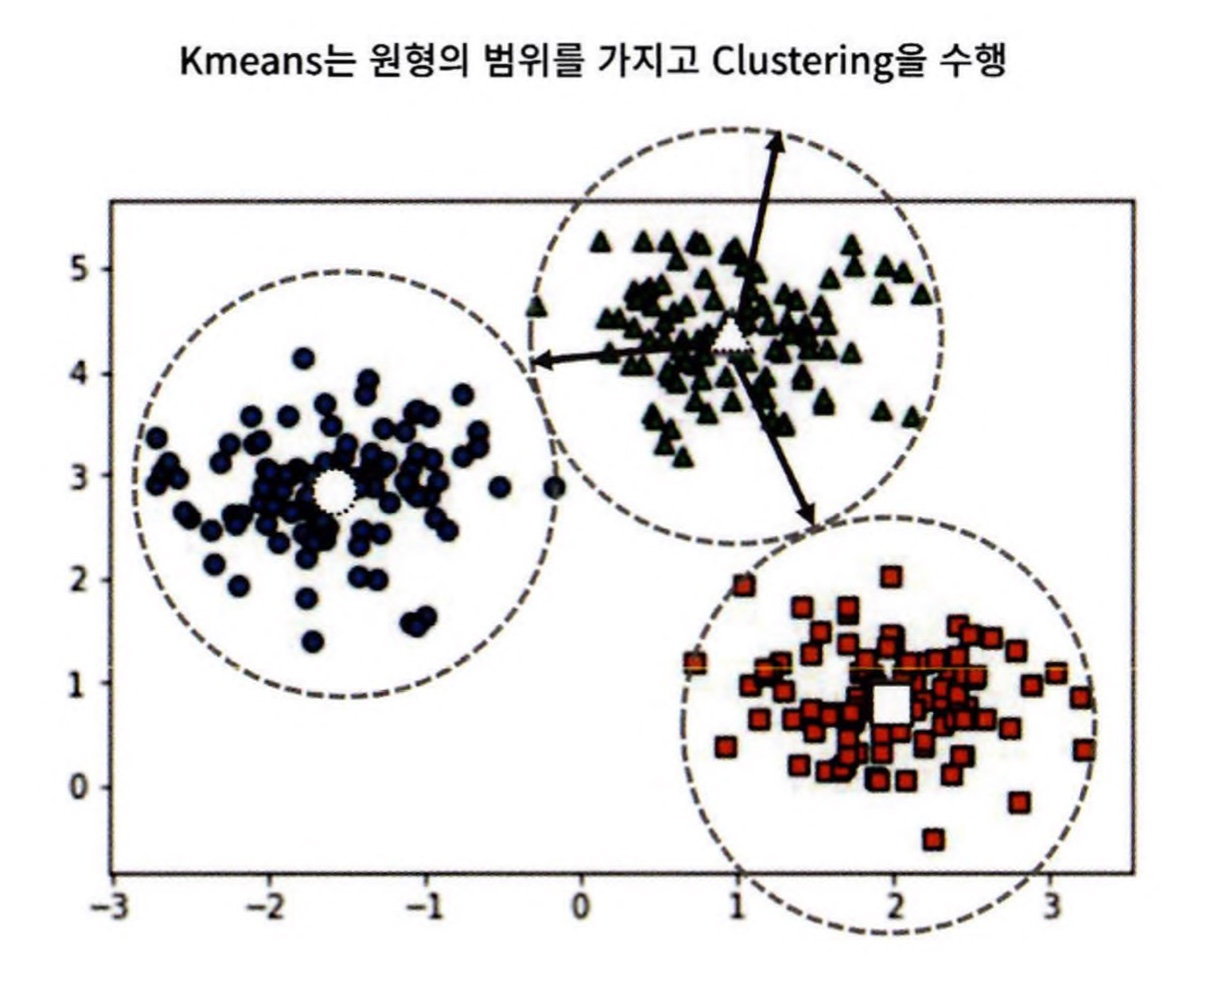




*   KMeans 군집화는 개별 군집의 중심에서 원형의 범위로 데이터를 군집화했으나, 데이터가 길쭉한 타원형으로 늘어선 경우 같이 데이터가 원형의 범위로 퍼져 있지 않은 경우 군집화를 잘 수행하지 못한다.
*   군집 시각화를 위한 별도의 visualize_cluster_plot() 함수를 정의한다.



In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
%matplotlib inline

def visualize_cluster_plot(cluster_result=None, dataframe=None, label_name='target', iscenter=True):
    if dataframe is None:
        print("Error: DataFrame is required.")
        return
    unique_labels = np.unique(dataframe[label_name])
    markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name] == label]
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
                    marker=markers[label % len(markers)])
        if iscenter and cluster_result is not None and hasattr(cluster_result, 'cluster_centers_'):

            center_x_y = cluster_result.cluster_centers_[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9,
                        marker=markers[label % len(markers)])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k',
                        marker='$%d$' % label)
    plt.show()

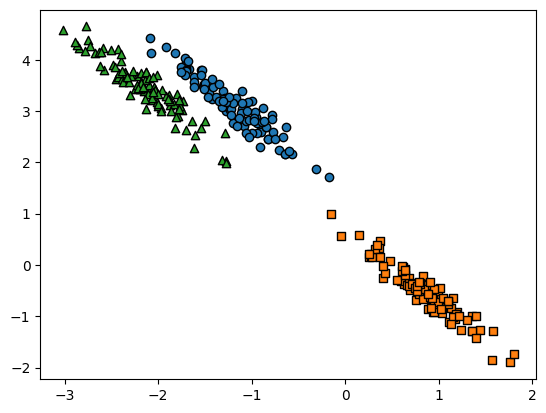

In [16]:
## make_blobs()의 군집의 수는 3개로, cluster_std는 0.5로 설정해 군집 내의 데이터를 뭉치게 유도한 데이터 세트에 KMeans를 적용한다
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.5, random_state=0)

## 길게 늘어난 타원형의 데이터 세트를 생성하기 위해 변환한다
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)

## feature 데이터 세트와 make_blobs()의 y 결과값을 DataFrame으로 저장한다
clusterDF = pd.DataFrame(data=X_aniso, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

## 생성된 데이터 세트를 target별로 다른 마커로 표시해 시각화한다
visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

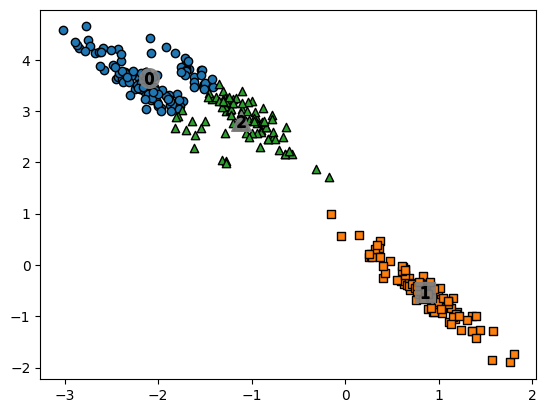

In [17]:
## 위의 데이터 세트에서 KMeans의 군집화 정확성이 떨어지는 것을 보완하기 위해 군집화를 다시 확인한다
## 3개의 군집 기반 KMeans를 X_aniso 데이터 세트에 적용한다
kmeans = KMeans(3, random_state=0)
kmeans_label = kmeans.fit_predict(X_aniso)
clusterDF['kmeans_label'] = kmeans_label

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_label', iscenter=True)

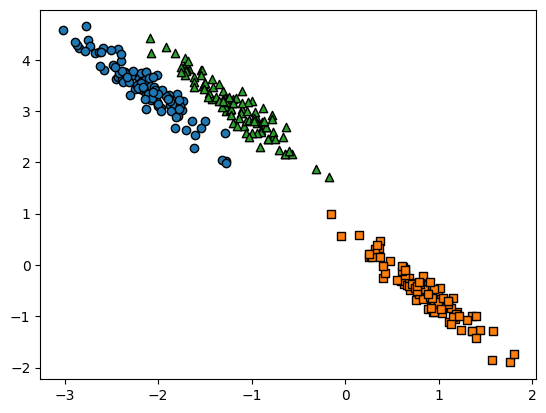

In [18]:
## GMM으로 군집화를 수행한다
## 3개의 n_components 기반 GMM을 X_aniso 데이터 세트에 적용한다
gmm = GaussianMixture(n_components=3, random_state=0)
gmm_label = gmm.fit(X_aniso).predict(X_aniso)
clusterDF['gmm_label'] = gmm_label

## GaussianMixture는 cluster_centers_ 속성이 없으므로 iscenter를 False로 설정한다
visualize_cluster_plot(gmm, clusterDF, 'gmm_label', iscenter=False)

In [19]:
## 데이터 세트에서의 군집화 효율 차이를 확인한다
print('### KMeans Clustering ###')
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

print('\n### Gaussian Mixture Clustering ###')
print(clusterDF.groupby('target')['gmm_label'].value_counts())

### KMeans Clustering ###
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64

### Gaussian Mixture Clustering ###
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64


Kmeans의 경우 군집 1번만 정확히 매핑되었지만, 나머지 군집의 경우 target 값과 어긋나는 경우가 발생하고 있다. 하지만 GMM의 경우 군집이 target 값과 잘 매핑되어 있다.
*   GMM의 경우 KMeans보다 유연하게 다양한 데이터 세트에 잘 적용될 수 있다는 장점이 있다.
*   하지만 GMM은 군집화를 위한 수행 시간이 오래 걸린다는 단점이 존재한다.

## DBSCAN(Density Based Spatial Clustering of Applications with Noise)
### DBSCAN 개요

*   DBSCAN은 밀도 기반 군집화의 대표적인 알고리즘으로, 간단하고 직관적인 알고리즘으로 돼있음에도 데이터의 분포가 기하학적으로 복잡한 데이터 세트에도 효과적인 군집화가 가능하다. 이는 특정 공간 내에 데이터 밀도 차이를 기반 알고리즘으로 하고 있기 때문이다.



